In [ ]:
import os
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
#from osgeo import gdal, osr, gdalconst, gdal_array

In [2]:
data1 = pd.read_csv(r"E:\新しいフォルダー\CH4\5p00\440ppm.csv")
display(data1)
data1=np.array(data1).T
data1 [1:,:] = data1[1:,:] * 100
print(data1)
display(data1)

,Waveln,0.00,0.25,0.50,0.75,1.00,1.25,1.50,1.75,2.00,2.25
0,380.0,5.593810,5.593130,5.592530,5.591850,5.591170,5.590330,5.589650,5.588970,5.588290,5.587610
1,381.0,6.571640,6.570830,6.569980,6.569170,6.568370,6.567510,6.566710,6.565900,6.565090,6.564280
2,382.0,5.375080,5.374420,5.373770,5.373100,5.372440,5.371760,5.371090,5.370430,5.369760,5.369090
3,383.0,4.413030,4.412480,4.411920,4.411360,4.410810,4.410250,4.409700,4.409140,4.408590,4.408040
4,384.0,4.126000,4.125480,4.124980,4.124460,4.123940,4.123380,4.122860,4.122340,4.121820,4.121300
...,...,...,...,...,...,...,...,...,...,...,...
2116,2496.0,0.121326,0.062221,0.035595,0.021046,0.012649,0.007697,0.004752,0.002998,0.001955,0.001336
2117,2497.0,0.126320,0.055959,0.034224,0.021828,0.014146,0.009251,0.006098,0.004062,0.002749,0.001904
2118,2498.0,0.126946,0.063409,0.040510,0.026846,0.018060,0.012240,0.008336,0.005706,0.003935,0.002748
2119,2499.0,0.125774,0.076959,0.054158,0.038811,0.027887,0.019989,0.014264,0.010132,0.007173,0.005073


[[3.80000e+02 3.81000e+02 3.82000e+02 ... 2.49800e+03 2.49900e+03
  2.50000e+03]
 [5.59381e+02 6.57164e+02 5.37508e+02 ... 1.26946e+01 1.25774e+01
  1.27030e+01]
 [5.59313e+02 6.57083e+02 5.37442e+02 ... 6.34093e+00 7.69587e+00
  7.45901e+00]
 ...
 [5.58897e+02 6.56590e+02 5.37043e+02 ... 5.70567e-01 1.01324e+00
  8.56905e-01]
 [5.58829e+02 6.56509e+02 5.36976e+02 ... 3.93543e-01 7.17259e-01
  5.95997e-01]
 [5.58761e+02 6.56428e+02 5.36909e+02 ... 2.74792e-01 5.07314e-01
  4.15492e-01]]


array([[3.80000e+02, 3.81000e+02, 3.82000e+02, ..., 2.49800e+03,
        2.49900e+03, 2.50000e+03],
       [5.59381e+02, 6.57164e+02, 5.37508e+02, ..., 1.26946e+01,
        1.25774e+01, 1.27030e+01],
       [5.59313e+02, 6.57083e+02, 5.37442e+02, ..., 6.34093e+00,
        7.69587e+00, 7.45901e+00],
       ...,
       [5.58897e+02, 6.56590e+02, 5.37043e+02, ..., 5.70567e-01,
        1.01324e+00, 8.56905e-01],
       [5.58829e+02, 6.56509e+02, 5.36976e+02, ..., 3.93543e-01,
        7.17259e-01, 5.95997e-01],
       [5.58761e+02, 6.56428e+02, 5.36909e+02, ..., 2.74792e-01,
        5.07314e-01, 4.15492e-01]], shape=(11, 2121))

In [3]:
# read radiometric file (csv)
def read_bfile(file):
    # ファイルのベース名に"_B.csv"を追加して新しいファイル名を作成
    fileb = os.path.splitext(file)[0] + "_B.csv"

    # CSVファイルをpandasを使って読み込む
    df = pd.read_csv(fileb)

    # パラメータ配列を初期化
    param = np.zeros((185, 5), dtype=float)

    # DataFrameからデータを抽出し、param配列に格納
    for i in range(min(185, len(df))):  # レコード数が185を超えないようにする
        for j in range(5):
            param[i, j] = float(df.iloc[i, j + 1])

    #'CenterWavelengthNanometer', 'FullWidthAtHalfMaximumNanometer',
    #'SolarIrradianceWatt/Meter2/Micron', 'ReflectanceMulti', 'ReflectanceAdd'

    return param


# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0]  # ファイルの拡張子を削除し、ベース名を取得
    fileb = fileb + ".txt"  # ベース名に".txt"を追加して、新しいファイル名を作成
    csv_file = open(fileb, 'r')  # txtファイルを読み取りモードで開く
    record_list = []  # レコードを格納するリストを初期化
    record = csv_file.readline()  # 2行目から読み込みを開始

    while record :  # ファイルの終わりまでループ
        record_list.append(record.rstrip().split('='))  # 各行を読み込み、改行文字を取り除き'='で分割してリストにし、record_listに追加
        record = csv_file.readline()  # 次の行を読み込む

    for record in record_list:  # 全レコードをループ
        if(record[0]=='RadianceMultiVNIR                                                      '):
            radiancemultivnir = float(record[1])
        if(record[0]=='RadianceAddVNIR                                                        '):
            radianceaddvnir = float(record[1])
        if(record[0]=='RadianceMultiSWIR                                                      '):
            radiancemultiswir = float(record[1])
        if(record[0]=='RadianceAddSWIR                                                        '):
            radianceaddswir = float(record[1])
    return radiancemultivnir, radiancemultiswir, radianceaddvnir, radianceaddswir


# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    im = np.ones([img.shape[0], img.shape[1]])  # 画像の高さと幅に基づいて、全ての要素が1のマスクを作成

    # no data area
    im[img[:,:,10] == 0] = 0  # 画像のバンド10が0の位置に対して、マスクを0に設定（データがない領域を示す）

    # change to float
    img = 1.0 * img  # 入力画像を浮動小数点数型に変換

    # apply radiometric vnir
    for j in range(58):  # 0から57バンド（VNIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultivnir + radaddvnir  # 各バンドの値にradmultivnirを掛けてradaddvnirを加える

    # apply radiometric swir
    for j in range(58, 185):  # 58から184バンド（SWIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultiswir + radaddswir  # 各バンドの値にradmultiswirを掛けてradaddswirを加える

    img[im == 0] = 0  # マスクが0の位置（データがない領域）に対して、画像の値を0に設定

    return img


# show hyper image
def show_hyper(img, b=8, g=18, r=28):  # ハイパースペクトル画像から特定のバンドを取り出して表示するための関数
    ims = np.zeros([img.shape[0], img.shape[1], 3])  # 画像の高さ、幅、およびRGBの3チャンネルを持つゼロ配列を作成

    ims[:,:,0] = img[:,:,r]    #R
    ims[:,:,1] = img[:,:,g]    #G
    ims[:,:,2] = img[:,:,b]    #B

    max = np.max(ims)/5  # 画像配列の最大値を取得し、それを5で割った値を max として設定
    ims /= max  # 画像を max で割って正規化

    ims = np.clip(ims, 0.0, 1.0)  # 画像配列の値を0から1の範囲にクランプ

    plt.imshow(ims)
    plt.show()


# show spectral at (x, y)
def show_spectral(img, param, y, x):  # 指定した座標 (x, y) でのスペクトルデータを表示するための関数
    plt.plot(param[ 0: 58,0], img[y, x,  0: 58], label="VNIR Spectrum", color="r");
    plt.plot(param[58:185,0], img[y, x, 58:185], label="SWIR Spectrum", color="g");
    plt.xlabel("Wavelength (nm)", fontsize=18)
    plt.ylabel(r"Radiance (W/m$^2$/$\mu$m/sr)", fontsize=18)
    plt.tick_params(labelsize=16)
    plt.legend();	plt.tight_layout();	plt.show()


def get_spectral(img, param, y, x):
  return img[y,x,:]

# ピクセル空間から地理空間への変換
def show_xy(src, x, y):
    width = src.RasterXSize # srcラスターデータセットの横幅（列数）を取得し格納
    height = src.RasterYSize # srcラスターデータセットの縦幅（行数）を取得し格納
    gt = src.GetGeoTransform() # srcラスターデータセットのジオトランスフォーム（地理変換情報）を取得し、gtに格納
    # gtは6つの要素を持つタプルで、地理座標への変換情報を含む
    # gt[0]: 左上隅のX座標（地理座標系の原点のX座標）。
    # gt[1]: 水平方向のピクセル解像度（ピクセルサイズ、X方向のスケール）。
    # gt[2]: 水平方向の回転（通常は0）。
    # gt[3]: 左上隅のY座標（地理座標系の原点のY座標）。
    # gt[4]: 垂直方向の回転（通常は0）。
    # gt[5]: 垂直方向のピクセル解像度（ピクセルサイズ、Y方向のスケール。通常は負の値、地図の上が北である場合）。
    minx = gt[0]
    miny = gt[3] + width * gt[4] + height * gt[5]
    maxx = gt[0] + width * gt[1] + height * gt[2]
    maxy = gt[3]
    X = gt[0] + x * gt[1] + y * gt[2]
    Y = gt[3] + x * gt[4] + y * gt[5]
    return X, Y

# 地理空間から緯度経度(WGS84)に変換
def show_latlon(src, x, y):
    old_cs= osr.SpatialReference() # 元の座標系を入れるオブジェクト
    old_cs.ImportFromWkt(src.GetProjectionRef()) # データセットから取得した投影情報（WKT形式）
    # WGS84座標系のWKT（Well-Known Text）表現を文字列として定義
    wgs84_wkt = """
        GEOGCS["WGS 84",
            DATUM["WGS_1984",
                SPHEROID["WGS 84",6378137,298.257223563,
                    AUTHORITY["EPSG","7030"]],
                AUTHORITY["EPSG","6326"]],
            PRIMEM["Greenwich",0,
                AUTHORITY["EPSG","8901"]],
            UNIT["degree",0.01745329251994328,
                AUTHORITY["EPSG","9122"]],
            AUTHORITY["EPSG","4326"]]"""
    new_cs = osr.SpatialReference() # 新しい座標系を入れるオブジェクト
    new_cs .ImportFromWkt(wgs84_wkt) # 定義したWGS84のWKT文字列をインポート

    # old_csからnew_csへの座標変換を行うためのosr.CoordinateTransformationオブジェクトを作成し、transformに格納
    transform = osr.CoordinateTransformation(old_cs,new_cs)

    X, Y = show_xy(src, x, y) #ピクセル空間から地理空間への変換

    # 計算した地理座標XとYを、transformを使ってWGS84座標系（緯度経度）に変換、格納します
    latlong = transform.TransformPoint(X, Y)
    return latlong


# show hyper image
def interactive_latlon(src, img):  # ハイパースペクトル画像から特定のバンドを取り出して表示するための関数
    ims = np.zeros([img.shape[0], img.shape[1], 3])  # 画像の高さ、幅、およびRGBの3チャンネルを持つゼロ配列を作成
    ims[:,:,0] = img[:,:,28]    #R
    ims[:,:,1] = img[:,:,18]    #G
    ims[:,:,2] = img[:,:,8]    #B
    #max = np.max(ims) / 5  # 画像配列の最大値を取得し、それを5で割った値を max として設定
    #ims /= max  # 画像を max で割って正規化
    ims = np.clip(ims, 0.0, 255)  # 画像配列の値を0から1の範囲にクランプ

    fig = px.imshow(ims)

    click_js = '''
    <script>
        var myPlot = document.getElementsByClassName('plotly-graph-div')[0];
        myPlot.on('plotly_click', function(data){
            var x = data.points[0].x;
            var y = data.points[0].y;
            google.colab.kernel.invokeFunction('notebook.click_event', [x, y], {});
        });
    </script>
    '''

    # コールバック関数を定義
    def click_event(x,y):
        print("x", x, "y", y)
        X, Y = show_xy(src, x, y)
        lat, lon, nu = show_latlon(src, x, y)
        print("X", X, "Y", Y, "lat", lat, "lon", lon)
        show_spectral(img, param, y, x)

    # カーネルに関数を登録
    output.register_callback('notebook.click_event', click_event)

    # Plotlyの画像を表示
    fig.show()
    # カスタムJavaScriptを実行
    display(HTML(click_js))

In [217]:
def export_pixel_spectrum(img, param, x, y, output_csv_path="pixel_spectrum.csv"):
    """
    HISUI画像の指定座標 (x, y) におけるスペクトル（波長と放射輝度）をCSVファイルに保存。

    Parameters:
        img : np.ndarray
            放射補正済みのHISUI画像（shape: H, W, 185）
        param : np.ndarray
            read_bfile() で取得したバンド情報（shape: 185, 5）
        x, y : int
            ピクセル座標（画像の列、行）
        output_csv_path : str
            保存先CSVファイルパス（デフォルト: 'pixel_spectrum.csv'）
    """
    if img.ndim != 3 or img.shape[2] != 185:
        raise ValueError("img は (H, W, 185) の放射補正済みデータである必要があります")
    if param.shape[0] != 185:
        raise ValueError("param は 185バンドのバンド情報である必要があります")

    # 波長とスペクトル値を取得
    wavelengths = param[:, 0]            # shape: (185,)
    radiance = img[y, x, :]              # shape: (185,)

    # データフレーム作成
    df = pd.DataFrame({
        "Wavelength (nm)": wavelengths,
        "Radiance (W/m^2/μm/sr)": radiance
    })

    # CSV出力
    df.to_csv(output_csv_path, index=False)
    print(f"[OK] 座標 ({x}, {y}) のスペクトルを保存しました: {output_csv_path}")

In [218]:
from osgeo import gdal

tif_path = r"E:\メタン\2025_HISUI_72_The Permian Basin-論文照合用\HSHL1G_N320W1032_20221030160051_20231127193053\HSHL1G_N320W1032_20221030160051_20231127193053.tif"
src = gdal.Open(tif_path)
img = src.ReadAsArray().transpose(1, 2, 0)  # (B, H, W) → (H, W, B)

param = read_bfile(r"E:\メタン\2025_HISUI_72_The Permian Basin-論文照合用\HSHL1G_N320W1032_20221030160051_20231127193053\HSHL1G_N320W1032_20221030160051_20231127193053.")
radmultivnir, radmultiswir, radaddvnir, radaddswir = read_tfile(
    r"E:\メタン\2025_HISUI_72_The Permian Basin-論文照合用\HSHL1G_N320W1032_20221030160051_20231127193053\HSHL1G_N320W1032_20221030160051_20231127193053.txt"
)

img_corr = apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir)

export_pixel_spectrum(img_corr, param, x=1000, y=1501, output_csv_path=r"E:\メタン\a\pi1.csv")

[OK] 座標 (1000, 1501) のスペクトルを保存しました: E:\メタン\a\pi1.csv


In [4]:
data2 = pd.read_csv(r"E:\メタン\a\pi1.csv")
display(data2)
display(data1)

,Wavelength (nm),Radiance (W/m^2/μm/sr)
0,901.015,32.7680
1,913.505,42.8992
2,925.995,40.0320
3,938.485,25.5648
4,950.975,19.0976
...,...,...
122,2424.795,1.4432
123,2437.285,1.4304
124,2449.775,1.0816
125,2462.265,0.9632


array([[3.80000e+02, 3.81000e+02, 3.82000e+02, ..., 2.49800e+03,
        2.49900e+03, 2.50000e+03],
       [5.59381e+02, 6.57164e+02, 5.37508e+02, ..., 1.26946e+01,
        1.25774e+01, 1.27030e+01],
       [5.59313e+02, 6.57083e+02, 5.37442e+02, ..., 6.34093e+00,
        7.69587e+00, 7.45901e+00],
       ...,
       [5.58897e+02, 6.56590e+02, 5.37043e+02, ..., 5.70567e-01,
        1.01324e+00, 8.56905e-01],
       [5.58829e+02, 6.56509e+02, 5.36976e+02, ..., 3.93543e-01,
        7.17259e-01, 5.95997e-01],
       [5.58761e+02, 6.56428e+02, 5.36909e+02, ..., 2.74792e-01,
        5.07314e-01, 4.15492e-01]], shape=(11, 2121))

In [57]:
hi_i =58
hi_f =64
mo_i =1000
mo_f =2100
def extract_co2(data): #範囲の選択
    return data[:, mo_i:mo_f] #1950-2101nm



def estimated_by_co2(data, c): #二酸化炭素の量の推定, 5.0ppm刻みの水を線形補間#############-------------------------------ここ注意
    co2 = np.arange(0,  0.25 * (data.shape[0]-1), 0.25)
    position = np.searchsorted(co2, c)
    out = []
    for i in range(data.shape[1]):
        if position + 1 < data.shape[0]:  # インデックスが範囲外にならないようにチェック
            r = (co2[position] - c) / 0.25
            interpolated_value = r * data[position, i] + (1 - r) * data[position + 1, i]
        else:
            interpolated_value = data[position, i]  # 最後のインデックスの場合、次の値がないためそのままの値を使用
        out.append(interpolated_value)
    return out

def wavelength_adjustment_co2(data_co2, array, data_hisui):  #波長を線形補間する
    out = []
    wave_width = 1.0 #ここで波長の刻み幅を変える
    for i in range(hi_i,hi_f): #1950.175-2100.055nm
        position = np.searchsorted(array, data_hisui.iloc[i, 0]) #水の場所を求める
        r = (array[position] - data_hisui.iloc[i, 0]) / wave_width 
        out.append(r * data_co2[position - 1] + (1 - r) * data_co2[position])
    return out

def func_co2(data, data_hisui, sigma, mu, a, b, c, k):  #目的関数
    out = instrumental_function(data, sigma, mu)
    out = extract_co2(out)
    out = reflectance_correction(out, a, b, k)
    out = estimated_by_co2(out, c)
    out = wavelength_adjustment_co2(out, data[0, mo_i:mo_f], data_hisui)
    return out

def residuals_co2(param, data, data_hisui):  #残差
    sigma, mu, a, b, c, k = param
    w_est = func_co2(data, data_hisui, sigma, mu, a, b, c, k)
    return data_hisui.iloc[hi_i:hi_f,1] - w_est

def estimate_param_co2(data, data_hisui): #bの推定
    max_ref = max(data_hisui.iloc[hi_i:hi_f,1]) #1950.175-2100.055nm
    rel_max_index = np.argmax(data_hisui.iloc[hi_i:hi_f,1])
    abs_max_index = data_hisui.iloc[hi_i:hi_f].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]
    out = instrumental_function(data, sigma=6.5, mu=0.0)
    out = extract_co2(out)
    out = estimated_by_co2(out, c=1.8)
    out = wavelength_adjustment_co2(out, data[0, mo_i:mo_f], data_hisui)
    modtran = out[rel_max_index]
    b = max_ref / max_wave / modtran
    return b
    
def instrumental_function(data, sigma, mu): #装置関数
    column, row = data.shape #dataはMODTRAN6の結果
    x = data[0, :] #Wavelen
    out = np.zeros((column, row))
    out[0, :] = x
    ave = np.mean(x) #波長の平均値(中央値)
    gauss = np.exp(-(x - ave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi)) #ガウス関数
    for i in range(1, column):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same') #畳み込み
    return out

def reflectance_correction(data, a, b, k): #反射率の考慮, 一次近似で良い
    column, row = data.shape
    x = data[0, :]
    for i in range(1, column):
        data[i, :] = (a + b * x) * data[i, :] + k
    return data


Optimized parameters: [ 1.28127208e+01  1.94992476e+00 -1.62879114e+00  1.53588704e-03
  4.15477822e+00 -2.93943700e+01]
estimated water value: 4.154778217130868


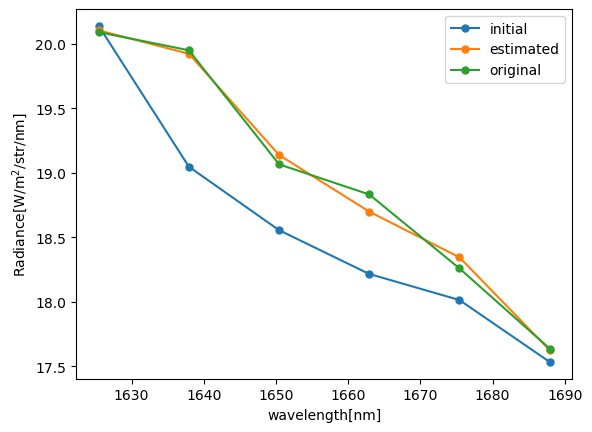

In [ ]:
# 初期パラメータの設定
b = estimate_param_co2(data1, data2)
a0 = np.array([12, 0, 0., b, 1.8, 0.0])
# 最適化の実行
res = least_squares(residuals_co2, a0, args=(data1, data2), method='lm')
print("Optimized parameters:", res.x)

# 結果の図示
w_int = func_co2(data1, data2, *a0)
w_est = func_co2(data1, data2, *res.x)
print("estimated water value:", res.x[4])
plt.plot(data2.iloc[58:64,0], w_int, "-o", label="initial", markersize=5)
plt.plot(data2.iloc[58:64,0], w_est, "-o", label="estimated", markersize=5)
plt.plot(data2.iloc[58:64,0], data2.iloc[58:64,1], "-o", label="original", markersize=5)
plt.xlabel('wavelength[nm]')
plt.ylabel('Radiance[W/m$^2$/str/nm]')
plt.legend()

Optimized parameters: [ 5.38712165e+00  4.78330358e+00  2.80642879e+00 -1.18827493e-03
  2.46768822e+00  2.78812966e+00]
estimated water value: 2.4676882209589466


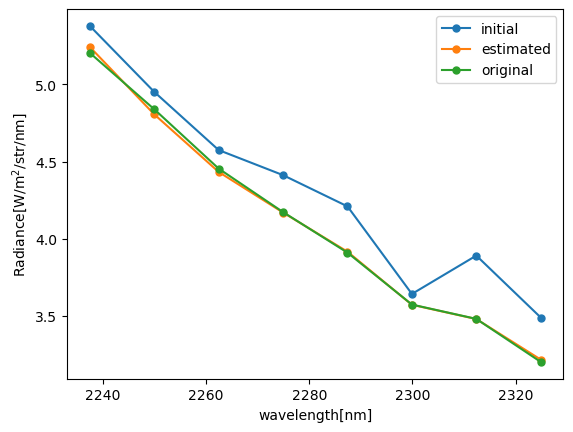

In [39]:
# 初期パラメータの設定
b = estimate_param_co2(data1, data2)
a0 = np.array([6.5, 4.783, 0., b, 1.8, 0.0])
# 最適化の実行
res = least_squares(residuals_co2, a0, args=(data1, data2), method='lm')
print("Optimized parameters:", res.x)

# 結果の図示
w_int = func_co2(data1, data2, *a0)
w_est = func_co2(data1, data2, *res.x)
print("estimated water value:", res.x[4])
plt.plot(data2.iloc[107:115,0], w_int, "-o", label="initial", markersize=5)
plt.plot(data2.iloc[107:115,0], w_est, "-o", label="estimated", markersize=5)
plt.plot(data2.iloc[107:115,0], data2.iloc[107:115,1], "-o", label="original", markersize=5)
plt.xlabel('wavelength[nm]')
plt.ylabel('Radiance[W/m$^2$/str/nm]')
plt.legend()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def show_used_wavelength_ranges(data1, data2, mo_i, mo_f, hi_i, hi_f, label="CO2"):
    # data1: 0行目が LUT の波長, data2: 0列目が HISUI の波長という前提
    w_lut   = data1[0, mo_i:mo_f]                  # LUT 側に使っている波長
    w_hisui = data2.iloc[hi_i:hi_f, 0].to_numpy()  # HISUI 側に使っている波長

    def stats(name, w):
        step = np.diff(w)
        print(f"{name}: [{w[0]:.3f} .. {w[-1]:.3f}] nm | N={w.size} | "
              f"step≈{np.median(step):.3f} nm (min={step.min():.3f}, max={step.max():.3f}) | "
              f"ascending={np.all(step>0)}")

    print(f"=== {label} wavelength ranges (slice end is exclusive) ===")
    print(f"LUT indices:   [{mo_i}:{mo_f}] -> effective last index = {mo_f-1}")
    stats("data1 (LUT) ", w_lut)
    print(f"HISUI indices: [{hi_i}:{hi_f}] -> effective last index = {hi_f-1}")
    stats("data2 (HISUI)", w_hisui)

    # カバレッジ確認（HISUI の範囲が LUT の中に収まっているか）
    inside = (w_hisui.min() >= w_lut.min()) and (w_hisui.max() <= w_lut.max())
    print("Coverage:", "OK (HISUI ⊆ LUT)" if inside else "⚠ HISUI 範囲が LUT 外を含んでいます")
    if not inside:
        print(f"    HISUI min={w_hisui.min():.3f}, LUT min={w_lut.min():.3f}; "
              f"HISUI max={w_hisui.max():.3f}, LUT max={w_lut.max():.3f}")

    return w_lut, w_hisui

# 使い方（あなたの変数そのまま）:
w_lut, w_hisui = show_used_wavelength_ranges(data1, data2, mo_i, mo_f, hi_i, hi_f, label="CO2")

# すでに描いている図に範囲を重ねて表示（任意）
plt.axvline(w_hisui[0], linestyle='--', alpha=0.5)
plt.axvline(w_hisui[-1], linestyle='--', alpha=0.5)
plt.title(f"CO2 band: LUT {w_lut[0]:.3f}-{w_lut[-1]:.3f} nm | HISUI {w_hisui[0]:.3f}-{w_hisui[-1]:.3f} nm")
plt.show()


In [ ]:
def extract_co2(data): #範囲の選択
    return data[:, 1570:1747] #1950-2101nm

def estimated_by_co2(data, c): #二酸化炭素の量の推定, 5.0ppm刻みの水を線形補間
    co2 = np.arange(380, 380 + 20 * (data.shape[0]-1), 20.0)
    position = np.searchsorted(co2, c)
    out = []
    for i in range(data.shape[1]):
        if position + 1 < data.shape[0]:  # インデックスが範囲外にならないようにチェック
            r = (co2[position] - c) / 20.0
            interpolated_value = r * data[position, i] + (1 - r) * data[position + 1, i]
        else:
            interpolated_value = data[position, i]  # 最後のインデックスの場合、次の値がないためそのままの値を使用
        out.append(interpolated_value)
    return out

def wavelength_adjustment_co2(data_co2, array, data_hisui):  #波長を線形補間する
    out = []
    wave_width = 1.0 #ここで波長の刻み幅を変える
    for i in range(84,99): #1950.175-2100.055nm
        position = np.searchsorted(array, data_hisui.iloc[i, 0]) #水の場所を求める
        r = (array[position] - data_hisui.iloc[i, 0]) / wave_width 
        out.append(r * data_co2[position - 1] + (1 - r) * data_co2[position])
    return out

def func_co2(data, data_hisui, sigma, mu, a, b, c,k):  #目的関数
    out = instrumental_function(data, sigma, mu)
    out = extract_co2(out)
    out = reflectance_correction(out, a, b,k)
    out = estimated_by_co2(out, c)
    out = wavelength_adjustment_co2(out, data[0, 1570:1747], data_hisui)
    return out

def residuals_co2(param, data, data_hisui):  #残差
    sigma, mu, a, b, c ,k= param
    w_est = func_co2(data, data_hisui, sigma, mu, a, b, c,k)
    return data_hisui.iloc[84:99,1] - w_est

def estimate_param_co2(data, data_hisui): #bの推定
    max_ref = max(data_hisui.iloc[84:99,1]) #1950.175-2100.055nm
    rel_max_index = np.argmax(data_hisui.iloc[84:99,1])
    abs_max_index = data_hisui.iloc[84:99].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]
    out = instrumental_function(data, sigma=6.5, mu=0.0)
    out = extract_co2(out)
    out = estimated_by_co2(out, c=420)
    out = wavelength_adjustment_co2(out, data[0, 1570:1747], data_hisui)
    modtran = out[rel_max_index]
    b = max_ref / max_wave / modtran
    return b

In [ ]:
def instrumental_function(data, sigma, mu): #装置関数
    column, row = data.shape #dataはMODTRAN6の結果
    x = data[0, :] #Wavelen
    out = np.zeros((column, row))
    out[0, :] = x
    ave = np.mean(x) #波長の平均値(中央値)
    gauss = np.exp(-(x - ave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi)) #ガウス関数
    for i in range(1, column):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same') #畳み込み
    return out

def extract_h2o(data): #範囲の選択
    return data[:, 645:865] #1025-1244nm

def reflectance_correction(data, a, b, k): #反射率の考慮, 一次近似で良い
    column, row = data.shape
    x = data[0, :]
    for i in range(1, column):
        data[i, :] = (a + b * x) * data[i, :] +k
    return data

In [ ]:
# 初期パラメータの設定
b = estimate_param_co2(data1, data2)
a0 = np.array([6.5, 0, 0.0, b, 420,0])
# 最適化の実行
res = least_squares(residuals_co2, a0, args=(data1, data2), method='lm')
print("Optimized parameters:", res.x)

# 結果の図示
w_int = func_co2(data1, data2, *a0)
w_est = func_co2(data1, data2, *res.x)
print("estimated water value:", res.x[4])
plt.title(res.x[4])
plt.plot(data2.iloc[84:99,0], w_int, "-o", color="blue", label="initial", markersize=5)
plt.plot(data2.iloc[84:99,0], w_est, "-o", color="red", label="estimated", markersize=5)
plt.plot(data2.iloc[84:99,0], data2.iloc[84:99,1], "-o", color="black", label="original", markersize=5)
plt.xlabel('wavelength[nm]')
plt.ylabel('Radiance[W/m$^2$/str/nm]')
plt.legend()